# 🌾 AgroGuard AI - Model Training on Google Colab

**Steps:**
1. Upload your dataset ZIP to Google Drive
2. Run this notebook with GPU enabled
3. Download the trained model files

**Runtime:** Go to Runtime → Change runtime type → Select **T4 GPU**

## Step 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

## Step 2: Install Dependencies

In [ ]:
!pip install tensorflow numpy matplotlib opencv-python-headless pillow scikit-learn -q

## Step 3: Upload Dataset

**Option A:** Upload ZIP file from your computer

In [ ]:
from google.colab import files
import zipfile
import os

# Upload the PlantVillage dataset ZIP
print("📤 Upload your PlantVillage dataset ZIP file...")
uploaded = files.upload()

# Extract the ZIP
for filename in uploaded.keys():
    print(f"\n📦 Extracting {filename}...")
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall('/content/archive')
    print("✅ Extraction complete!")

📤 Upload your PlantVillage dataset ZIP file...


KeyboardInterrupt: 

**Option B:** Use dataset from Google Drive (faster if already uploaded)

In [ ]:
# Uncomment and modify this if your dataset is in Google Drive
# !unzip -q '/content/drive/MyDrive/PlantVillage.zip' -d /content/archive

## Step 4: Prepare Dataset (Split into Train/Test)

In [ ]:
import os
import shutil
import random
from pathlib import Path

# Configuration
SOURCE_DIR = "/content/archive/PlantVillage"
TRAIN_DIR = "/content/dataset/train"
TEST_DIR = "/content/dataset/test"

SELECTED_CLASSES = {
    "Pepper__bell___Bacterial_spot": "Pepper_bell_Bacterial_spot",
    "Pepper__bell___healthy": "Pepper_bell_healthy",
    "Potato___Early_blight": "Potato_Early_blight",
    "Potato___Late_blight": "Potato_Late_blight",
    "Potato___healthy": "Potato_healthy",
    "Tomato_Early_blight": "Tomato_Early_blight",
    "Tomato_Late_blight": "Tomato_Late_blight",
    "Tomato_healthy": "Tomato_healthy",
    "Tomato_Bacterial_spot": "Tomato_Bacterial_spot",
    "Tomato_Leaf_Mold": "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot": "Tomato_Septoria_leaf_spot",
    "Tomato__Target_Spot": "Tomato_Target_Spot",
    "Tomato__Tomato_mosaic_virus": "Tomato_Mosaic_virus",
    "Tomato__Tomato_YellowLeaf__Curl_Virus": "Tomato_YellowLeaf_Curl_Virus",
    "Tomato_Spider_mites_Two_spotted_spider_mite": "Tomato_Spider_mites",
}

TRAIN_SPLIT = 0.8
MAX_PER_CLASS = 400  # Reduce for faster training

print("📂 Preparing dataset...\n")

train_path = Path(TRAIN_DIR)
test_path = Path(TEST_DIR)

for source_class, target_class in SELECTED_CLASSES.items():
    source_folder = Path(SOURCE_DIR) / source_class

    if not source_folder.exists():
        print(f"  ⚠️  Skipping {source_class} - not found")
        continue

    images = list(source_folder.glob("*.JPG")) + list(source_folder.glob("*.jpg")) + list(source_folder.glob("*.png"))

    if not images:
        continue

    if MAX_PER_CLASS and len(images) > MAX_PER_CLASS:
        images = random.sample(images, MAX_PER_CLASS)

    random.shuffle(images)
    split_idx = int(len(images) * TRAIN_SPLIT)
    train_images = images[:split_idx]
    test_images = images[split_idx:]

    train_class_dir = train_path / target_class
    test_class_dir = test_path / target_class
    train_class_dir.mkdir(parents=True, exist_ok=True)
    test_class_dir.mkdir(parents=True, exist_ok=True)

    for img in train_images:
        shutil.copy2(img, train_class_dir / img.name)

    for img in test_images:
        shutil.copy2(img, test_class_dir / img.name)

    print(f"  ✅ {target_class}: Train={len(train_images)}, Test={len(test_images)}")

print("\n✅ Dataset preparation complete!")

📂 Preparing dataset...

  ✅ Pepper_bell_Bacterial_spot: Train=320, Test=80
  ✅ Pepper_bell_healthy: Train=320, Test=80
  ✅ Potato_Early_blight: Train=320, Test=80
  ✅ Potato_Late_blight: Train=320, Test=80
  ✅ Potato_healthy: Train=121, Test=31
  ✅ Tomato_Early_blight: Train=320, Test=80
  ✅ Tomato_Late_blight: Train=320, Test=80
  ✅ Tomato_healthy: Train=320, Test=80
  ✅ Tomato_Bacterial_spot: Train=320, Test=80
  ✅ Tomato_Leaf_Mold: Train=320, Test=80
  ✅ Tomato_Septoria_leaf_spot: Train=320, Test=80
  ✅ Tomato_Target_Spot: Train=320, Test=80
  ✅ Tomato_Mosaic_virus: Train=298, Test=75
  ✅ Tomato_YellowLeaf_Curl_Virus: Train=320, Test=80
  ✅ Tomato_Spider_mites: Train=320, Test=80

✅ Dataset preparation complete!


## Step 5: Build and Train CNN Model

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# Configuration
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 20

os.makedirs("/content/model", exist_ok=True)

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)

test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)

NUM_CLASSES = train_data.num_classes
print(f"\n✅ Found {NUM_CLASSES} classes: {list(train_data.class_indices.keys())}\n")

# Save class names
with open("/content/model/class_names.json", "w") as f:
    json.dump(train_data.class_indices, f, indent=2)
print("✅ class_names.json saved.")

Found 4579 images belonging to 15 classes.
Found 1146 images belonging to 15 classes.

✅ Found 15 classes: ['Pepper_bell_Bacterial_spot', 'Pepper_bell_healthy', 'Potato_Early_blight', 'Potato_Late_blight', 'Potato_healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Mosaic_virus', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites', 'Tomato_Target_Spot', 'Tomato_YellowLeaf_Curl_Virus', 'Tomato_healthy']

✅ class_names.json saved.


In [ ]:
# Build CNN Model
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.2),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.2),

    # Block 4
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.2),

    # Dense layers
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,112,367 (34.76 MB)

 Trainable params: 9,109,423 (34.75 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
# Callbacks
callbacks = [
    ModelCheckpoint(
        "/content/model/crop_disease_model.h5",
        save_best_only=True,
        monitor="val_accuracy",
        verbose=1
    ),
    ReduceLROnPlateau(
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        monitor="val_loss"
    ),
]

# Start Training
print("\n🚀 Starting training with GPU acceleration...\n")
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS,
    callbacks=callbacks,
)


🚀 Starting training with GPU acceleration...

Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.2771 - loss: 2.5815
Epoch 1: val_accuracy improved from None to 0.12740, saving model to /content/model/crop_disease_model.h5



Epoch 1: finished saving model to /content/model/crop_disease_model.h5
144/144 ━━━━━━━━━━━━━━━━━━━━ 66s 302ms/step - accuracy: 0.3693 - loss: 2.1141 - val_accuracy: 0.1274 - val_loss: 14.8135 - learning_rate: 0.0010
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.5021 - loss: 1.5333
Epoch 2: val_accuracy did not improve from 0.12740
144/144 ━━━━━━━━━━━━━━━━━━━━ 48s 185ms/step - accuracy: 0.5508 - loss: 1.3912 - val_accuracy: 0.0785 - val_loss: 13.6282 - learning_rate: 0.0010
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.6284 - loss: 1.1244
Epoch 3: val_accuracy did not improve from 0.12740
144/144 ━━━━━━━━━━━━━━━━━━━━ 26s 182ms/step - accuracy: 0.6425 - loss: 1.0768 - val_accuracy: 0.1239 - val_loss: 8.9317 - learning_rate: 0.0010
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.6922 - loss: 0.9380
Epoch 4: val_accuracy improved from 0.12740 to 0.40750, saving model to /content/model/crop_disease_model.h5



Epoch 4: finished saving model to /content/model/crop_disease_model.h5
144/144 ━━━━━━━━━━━━━━━━━━━━ 27s 188ms/step - accuracy: 0.6868 - loss: 0.9355 - val_accuracy: 0.4075 - val_loss: 2.6119 - learning_rate: 0.0010
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7022 - loss: 0.9036
Epoch 5: val_accuracy improved from 0.40750 to 0.69721, saving model to /content/model/crop_disease_model.h5



Epoch 5: finished saving model to /content/model/crop_disease_model.h5
144/144 ━━━━━━━━━━━━━━━━━━━━ 28s 192ms/step - accuracy: 0.6818 - loss: 0.9641 - val_accuracy: 0.6972 - val_loss: 1.0081 - learning_rate: 0.0010
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7406 - loss: 0.7825
Epoch 6: val_accuracy did not improve from 0.69721
144/144 ━━━━━━━━━━━━━━━━━━━━ 27s 188ms/step - accuracy: 0.7388 - loss: 0.7975 - val_accuracy: 0.4686 - val_loss: 3.1224 - learning_rate: 0.0010
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7277 - loss: 0.8134
Epoch 7: val_accuracy did not improve from 0.69721
144/144 ━━━━━━━━━━━━━━━━━━━━ 27s 190ms/step - accuracy: 0.7576 - loss: 0.7241 - val_accuracy: 0.4991 - val_loss: 2.3512 - learning_rate: 0.0010
Epoch 8/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7724 - loss: 0.6801
Epoch 8: val_accuracy did not improve from 0.69721
144/144 ━━━━━━━━━━━━━━━━━━━━ 27s 188ms/step - accuracy: 0.7259 - loss: 0.8359 -


Epoch 9: finished saving model to /content/model/crop_disease_model.h5
144/144 ━━━━━━━━━━━━━━━━━━━━ 28s 191ms/step - accuracy: 0.7626 - loss: 0.7157 - val_accuracy: 0.7871 - val_loss: 0.6082 - learning_rate: 5.0000e-04
Epoch 10/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.8092 - loss: 0.5713
Epoch 10: val_accuracy did not improve from 0.78709
144/144 ━━━━━━━━━━━━━━━━━━━━ 27s 191ms/step - accuracy: 0.8111 - loss: 0.5654 - val_accuracy: 0.7670 - val_loss: 0.7280 - learning_rate: 5.0000e-04
Epoch 11/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8340 - loss: 0.4968
Epoch 11: val_accuracy did not improve from 0.78709
144/144 ━━━━━━━━━━━━━━━━━━━━ 27s 189ms/step - accuracy: 0.8373 - loss: 0.4931 - val_accuracy: 0.3473 - val_loss: 4.1895 - learning_rate: 5.0000e-04
Epoch 12/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7570 - loss: 0.7195
Epoch 12: val_accuracy did not improve from 0.78709
144/144 ━━━━━━━━━━━━━━━━━━━━ 27s 188ms/step - accuracy: 0.793


Epoch 18: finished saving model to /content/model/crop_disease_model.h5
144/144 ━━━━━━━━━━━━━━━━━━━━ 29s 200ms/step - accuracy: 0.8303 - loss: 0.5165 - val_accuracy: 0.7949 - val_loss: 0.6893 - learning_rate: 1.2500e-04
Epoch 19/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8384 - loss: 0.4756
Epoch 19: val_accuracy did not improve from 0.79494
144/144 ━━━━━━━━━━━━━━━━━━━━ 28s 193ms/step - accuracy: 0.8476 - loss: 0.4595 - val_accuracy: 0.7923 - val_loss: 0.7230 - learning_rate: 6.2500e-05
Epoch 20/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8660 - loss: 0.4072
Epoch 20: val_accuracy did not improve from 0.79494
144/144 ━━━━━━━━━━━━━━━━━━━━ 28s 193ms/step - accuracy: 0.8546 - loss: 0.4309 - val_accuracy: 0.7356 - val_loss: 0.9900 - learning_rate: 6.2500e-05


## Step 6: Plot Training Results

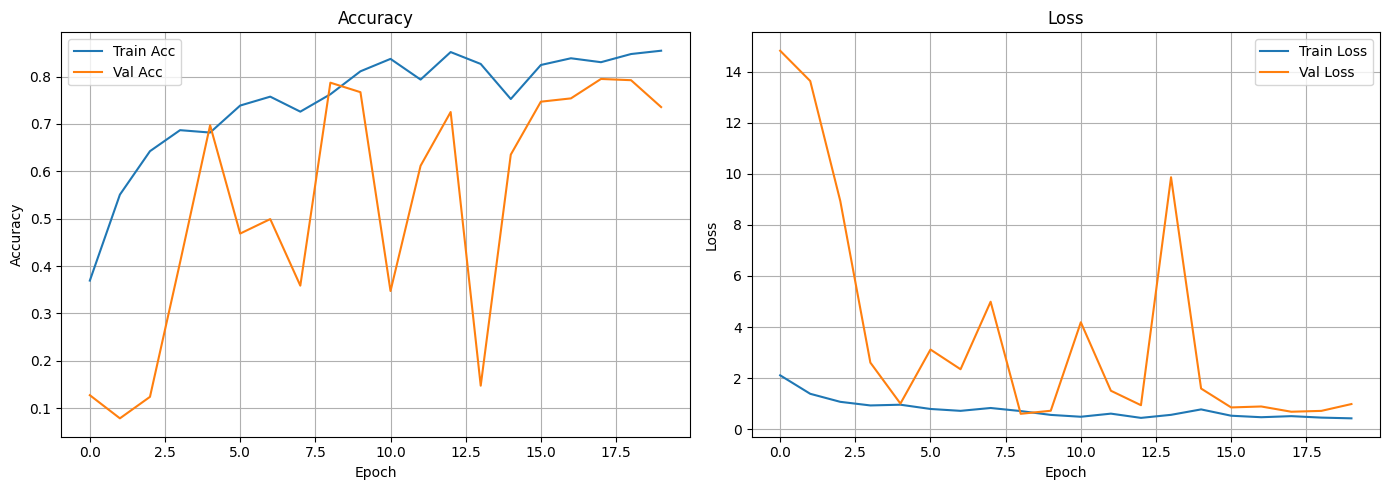


✅ Training complete!
Final Training Accuracy: 0.8546
Final Validation Accuracy: 0.7356


In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="Train Acc")
axes[0].plot(history.history["val_accuracy"], label="Val Acc")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("/content/model/training_curves.png", dpi=150)
plt.show()

print("\n✅ Training complete!")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

## Step 7: Download Trained Model Files

In [ ]:
# Create a ZIP file with model files
import shutil

shutil.make_archive('/content/trained_model', 'zip', '/content/model')

print("📦 Model files packaged!")
print("\nDownloading model files...")

files.download('/content/trained_model.zip')

print("\n✅ Download complete!")
print("\nExtract the ZIP and copy these files to your backend/model/ folder:")
print("  - crop_disease_model.h5")
print("  - class_names.json")
print("  - training_curves.png")

📦 Model files packaged!



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download complete!

Extract the ZIP and copy these files to your backend/model/ folder:
  - crop_disease_model.h5
  - class_names.json
  - training_curves.png


## Step 8: Test the Model (Optional)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


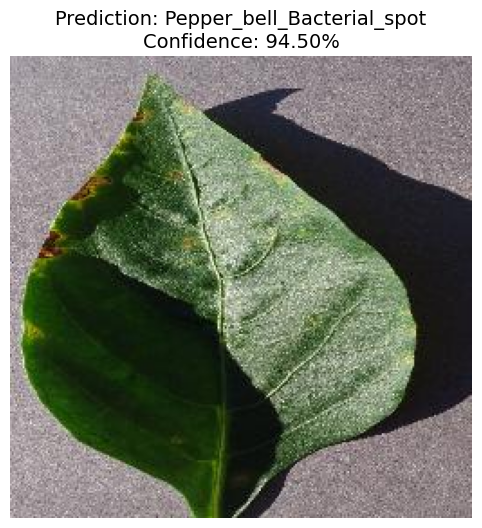


✅ Predicted: Pepper_bell_Bacterial_spot
   Confidence: 94.50%
   Actual: Pepper_bell_Bacterial_spot


In [ ]:
# Load class names
with open("/content/model/class_names.json") as f:
    class_data = json.load(f)

class_names = [k for k, v in sorted(class_data.items(), key=lambda x: x[1])]

# Test on a sample image
import cv2
from tensorflow.keras.models import load_model

# Get a random test image
test_class = list(Path(TEST_DIR).iterdir())[0]
test_image = list(test_class.glob("*.JPG"))[0]

# Preprocess
img = cv2.imread(str(test_image))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (128, 128))
img_array = img_resized / 255.0
img_array = np.reshape(img_array, (1, 128, 128, 3))

# Predict
predictions = model.predict(img_array)[0]
top_idx = np.argmax(predictions)
confidence = predictions[top_idx] * 100
predicted_class = class_names[top_idx]

# Display
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%", fontsize=14)
plt.axis('off')
plt.show()

print(f"\n✅ Predicted: {predicted_class}")
print(f"   Confidence: {confidence:.2f}%")
print(f"   Actual: {test_class.name}")